# 01 - Data Exploration

Exploratory analysis of the two training datasets used to detect malicious login forms.

## 1. Load & Clean Data

In [37]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from collections import Counter

pd.set_option("display.max_columns", None)   # show every column, no truncation
pd.set_option("display.width", None)

# load training data (login: sep=';' with header; no_form: comma + index col)
lf = pd.read_csv("../data/train/train_login_form-2026-08.csv", sep=";")
nf = pd.read_csv("../data/train/train_no_form-2026-08.csv", index_col=0)

if "schreenshot_path" in nf.columns:
    nf.drop(columns=["schreenshot_path"], inplace=True)
lf.dropna(subset=["html_signature"], inplace=True)
nf.dropna(subset=["html_signature"], inplace=True)
lf.reset_index(drop=True, inplace=True)
nf.reset_index(drop=True, inplace=True)

df = pd.concat([lf, nf], ignore_index=True)

print(f"login_form rows : {len(lf)}")
print(f"no_form rows    : {len(nf)}")
print(f"combined rows   : {len(df)}")
print()
print(f"Columns: {df.columns.tolist()}")
df.head(10)

login_form rows : 878
no_form rows    : 1212
combined rows   : 2090

Columns: ['url', 'label', 'reason', 'host_id', 'html_signature']


,url,label,reason,host_id,html_signature
0,https://jbarvin1.wixsite.com/website,LOGIN_FORM_MALICIOUS,NaN,24309772.0,(body(script)(script)(script)(script)(script)(...
1,https://igq.bbn.mybluehost.me/es/bbva_2026/log...,LOGIN_FORM_MALICIOUS,NaN,24330270.0,(body(div(header(div(div(img))(ul(li)(li)(li(a...
2,https://energetic-cause-516650.framer.app,LOGIN_FORM_MALICIOUS,NaN,24183401.0,(body(script)(div(style)(div(div(form(div(div(...
3,https://pedagiodigital-azure.vercel.app,LOGIN_FORM_MALICIOUS,NaN,24519910.0,(body(div)(script)(script)(script)(script)(scr...
4,https://growotpiagemhack2021.weebly.com,LOGIN_FORM_MALICIOUS,NaN,24579887.0,(body(div(div(div(div(ul(li(a(span)))(li(a(spa...
5,https://orange79.godaddysites.com,LOGIN_FORM_MALICIOUS,NaN,24145269.0,(body(div(div(div(div(div(div(div)(section(div...
6,https://office-oneshare-file8-osiwin.squarespa...,LOGIN_FORM_MALICIOUS,NaN,24379264.0,(body(div(div(div(div(div(img)(span)(span)(div...
7,https://servpproxmus-bit.github.io,LOGIN_FORM_MALICIOUS,NaN,24145339.0,(body(script)(div(style)(div(form(label(div)(d...
8,https://frc301.wixsite.com/fairpoint7,LOGIN_FORM_MALICIOUS,NaN,24270406.0,(body(script)(script)(script)(script)(script)(...
9,https://customdlesder.framer.website,LOGIN_FORM_MALICIOUS,NaN,24270525.0,(body(script)(div(style)(div(style)(div(div(di...


## 2. Duplicate Signatures

Identical signatures across pages - the same template deployed across multiple domains. We identify and remove duplicates before analysis to avoid biases in the feature distributions.

In [38]:
print("DUPLICATE SIGNATURES")
for label, subset in [(df_label, df[df["label"] == df_label]) for df_label in df["label"].unique()]:
    total  = len(subset)
    unique = subset["html_signature"].nunique()
    dupes  = total - unique
    print(f"\n{label}")
    print(f"  Total pages      : {total}")
    print(f"  Unique signatures: {unique}")
    print(f"  Duplicates       : {dupes}  ({dupes/total*100:.1f}%)")

def top_duplicates(frame, n=10):
    t = (
        frame["html_signature"]
        .value_counts()
        .loc[lambda s: s > 1]
        .head(n)
        .reset_index()
    )
    t.columns = ["html_signature", "count"]
    t["signature_preview"] = t["html_signature"].str[:120] + "..."
    return t[["count", "signature_preview"]]

print("\nTop 10 duplicate signatures in login_form dataset:")
lf_dupes = top_duplicates(lf)
display(lf_dupes if not lf_dupes.empty else "None — all login_form signatures are unique")

print("\nTop 10 duplicate signatures in no_form dataset:")
nf_dupes = top_duplicates(nf)
display(nf_dupes if not nf_dupes.empty else "None — all no_form signatures are unique")

DUPLICATE SIGNATURES

LOGIN_FORM_MALICIOUS
  Total pages      : 878
  Unique signatures: 878
  Duplicates       : 0  (0.0%)

NO_FORM
  Total pages      : 1212
  Unique signatures: 1194
  Duplicates       : 18  (1.5%)

Top 10 duplicate signatures in login_form dataset:


'None — all login_form signatures are unique'


Top 10 duplicate signatures in no_form dataset:


,count,signature_preview
0,4,(body(script)(div(div(div(div(div(div(a))(div(...
1,4,(body(noscript(style)(div(img)))(script)(scrip...
2,2,(body(div(div(a(img))(a(img))(a(img))(div)))(d...
3,2,(body)...
4,2,(body(div(div(div(img))(div(div(div(input))))(...
5,2,(body(div(div(div(div(div(div(div(figure(div(s...
6,2,(body(div)(style)(div(div(video(source))))(div...
7,2,(body(div(div(a)))(div(div)(script)(div(div(di...
8,2,(body(div)(script)(div(div(div(svg(g(g(path)))...
9,2,(body(a)(div(div(div(img))(header(div(a(span(s...


## 3. Remove Duplicate Signatures

Drop duplicate `html_signature` rows keeping the first occurrence per class. This ensures downstream tag frequency and sequence analyses are not skewed.

In [39]:
before = len(df)
df = df.drop_duplicates(subset=["html_signature"]).reset_index(drop=True)
lf  = df[df["label"] == "LOGIN_FORM_MALICIOUS"].reset_index(drop=True)
nf  = df[df["label"] == "NO_FORM"].reset_index(drop=True)
after = len(df)

print("AFTER DEDUPLICATION")
print(f"  Rows before : {before}")
print(f"  Rows removed: {before - after}")
print(f"  Rows after  : {after}")
print()
print(df["label"].value_counts().to_string())

AFTER DEDUPLICATION
  Rows before : 2090
  Rows removed: 18
  Rows after  : 2072

label
NO_FORM                 1194
LOGIN_FORM_MALICIOUS     878


## 4. Class Balance

Set                       MALICIOUS            NO_FORM            Total
Training set                 878 (42.4%)    1194 (57.6%)    2072
Retest Set                   105 (50.5%)     103 (49.5%)     208


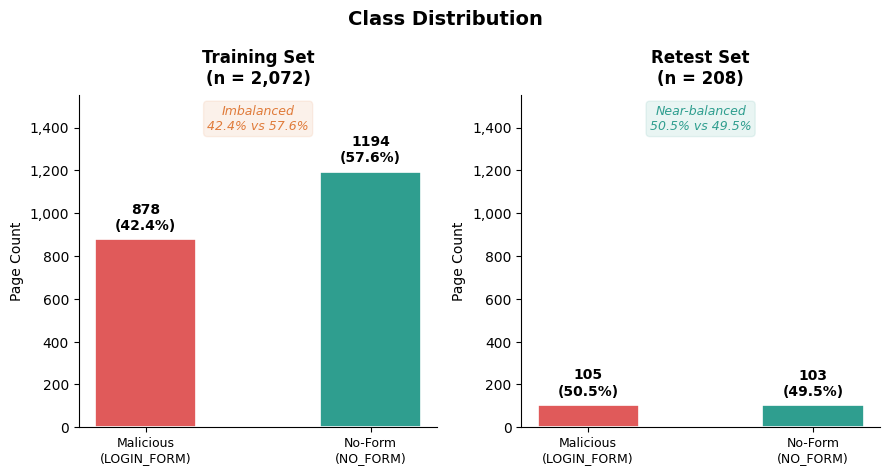

In [40]:
# retest set 
lf_rt = pd.read_csv('../data/retest/signed_retest_login_form.csv', index_col=0)
nf_rt = pd.read_csv('../data/retest/signed_retest_no_form.csv',    index_col=0)
df_rt = pd.concat([lf_rt, nf_rt], ignore_index=True)
df_rt.dropna(subset=['html_signature'], inplace=True)
df_rt['label'] = df_rt['label'].map({
    'TEST_LOGIN_FORM': 'LOGIN_FORM_MALICIOUS',
    'TEST_NO_FORM':    'NO_FORM',
})

CLASSES = ['LOGIN_FORM_MALICIOUS', 'NO_FORM']
train_counts  = df['label'].value_counts().reindex(CLASSES)
retest_counts = df_rt['label'].value_counts().reindex(CLASSES)

print(f"{'Set':<25} {'MALICIOUS':<20} {'NO_FORM':<18} {'Total'}")
for name, counts in [('Training set', train_counts), ('Retest Set', retest_counts)]:
    t = counts.sum()
    print(f"{name:<25} {counts['LOGIN_FORM_MALICIOUS']:>6} ({counts['LOGIN_FORM_MALICIOUS']/t*100:.1f}%)"
          f"  {counts['NO_FORM']:>6} ({counts['NO_FORM']/t*100:.1f}%)  {t:>6}")

PALETTE = ['#e05a5a', '#2f9e8f']
LABELS  = ['Malicious\n(LOGIN_FORM)', 'No-Form\n(NO_FORM)']

fig, axes = plt.subplots(1, 2, figsize=(9, 4.8))

datasets  = [train_counts, retest_counts]
titles    = [f'Training Set\n(n = {train_counts.sum():,})',
             f'Retest Set\n(n = {retest_counts.sum():,})']
notes     = ['Imbalanced\n42.4% vs 57.6%', 'Near-balanced\n50.5% vs 49.5%']
note_cols = ['#e07b3a', '#2f9e8f']
y_max = max(train_counts.max(), retest_counts.max()) * 1.30

for ax, counts, title, note, nc in zip(axes, datasets, titles, notes, note_cols):
    vals = [counts['LOGIN_FORM_MALICIOUS'], counts['NO_FORM']]
    bars = ax.bar(LABELS, vals, color=PALETTE, edgecolor='white', width=0.45, linewidth=1.2)

    ax.set_title(title, fontsize=12, fontweight='bold', pad=8)
    ax.set_ylabel('Page Count', fontsize=10)
    ax.set_ylim(0, y_max)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='x', labelsize=9)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

    total = sum(vals)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + y_max * 0.02,
                f'{val}\n({val/total*100:.1f}%)',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax.text(0.5, 0.97, note, transform=ax.transAxes,
            ha='center', va='top', fontsize=9, color=nc, fontstyle='italic',
            bbox=dict(boxstyle='round,pad=0.3', facecolor=nc, alpha=0.10, edgecolor=nc))

plt.suptitle('Class Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 5. Signature Length Distribution

Signature length statistics by class:
                       count    mean      std   min     25%     50%     75%       max
label                                                                                
LOGIN_FORM_MALICIOUS   878.0  1173.0   1786.6  36.0   515.2   739.0  1210.8   32683.0
NO_FORM               1194.0  8649.1  14740.6   6.0  2566.0  4966.0  9200.0  260769.0


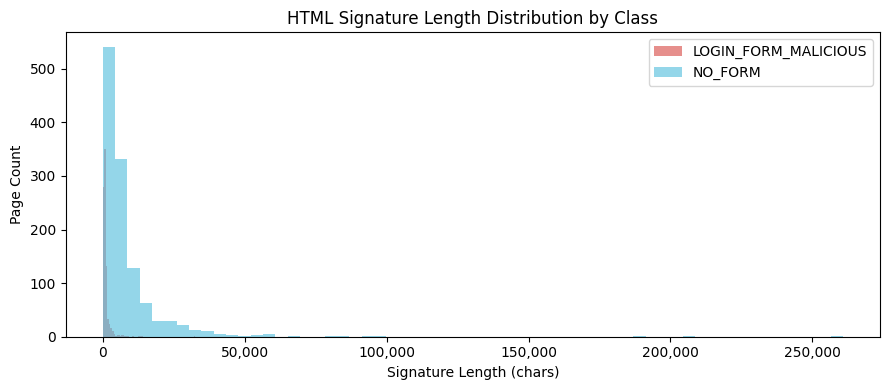

In [41]:
df["sig_len"] = df["html_signature"].str.len()

print("Signature length statistics by class:")
print(df.groupby("label")["sig_len"].describe().round(1).to_string())

fig, ax = plt.subplots(figsize=(9, 4))
for label, color in [("LOGIN_FORM_MALICIOUS", "#d9534f"), ("NO_FORM", "#5bc0de")]:
    subset = df[df["label"] == label]["sig_len"]
    ax.hist(subset, bins=60, alpha=0.65, color=color, label=label, edgecolor="none")
ax.set_xlabel("Signature Length (chars)")
ax.set_ylabel("Page Count")
ax.set_title("HTML Signature Length Distribution by Class")
ax.legend()
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

## 6. Tag Presence Rate by Class

In [42]:
MALICIOUS_TAGS   = ["form", "input", "label", "iframe", "style"]
BENIGN_TAGS      = ["nav", "footer", "header", "li"]
TAGS_OF_INTEREST = MALICIOUS_TAGS + BENIGN_TAGS
CREDENTIAL_GROUP = ["form", "input", "label", "iframe", "style"]

def tag_presence(sig, tag):
    return int(bool(re.search(rf"\({tag}\b", sig)))

for tag in TAGS_OF_INTEREST:
    df[f"has_{tag}"] = df["html_signature"].apply(lambda s, t=tag: tag_presence(s, t))

tag_cols = [f"has_{t}" for t in TAGS_OF_INTEREST]
presence = df.groupby("label")[tag_cols].mean().T * 100
presence.index = TAGS_OF_INTEREST
presence.columns.name = None
presence["Gap (pp)"] = (presence["LOGIN_FORM_MALICIOUS"] - presence["NO_FORM"]).round(2)
presence["Role"]     = ["Malicious signal"] * len(MALICIOUS_TAGS) + ["Benign signal"] * len(BENIGN_TAGS)
presence["Cred. Group"] = ["Yes" if t in CREDENTIAL_GROUP else "" for t in TAGS_OF_INTEREST]

table = presence[["Role", "LOGIN_FORM_MALICIOUS", "NO_FORM", "Gap (pp)", "Cred. Group"]].round(2)
table.columns = ["Role", "Malicious (%)", "No-Form (%)", "Gap", "Cred. Group"]
table.index.name = "Tag"

print("MALICIOUS SIGNALS")
print(table[table["Role"] == "Malicious signal"].drop(columns="Role").to_string())

MALICIOUS SIGNALS
        Malicious (%)  No-Form (%)    Gap Cred. Group
Tag                                                  
form            93.96        63.23  30.73         Yes
input           98.29        76.30  21.99         Yes
label           84.85        57.79  27.06         Yes
iframe          54.33        73.95 -19.63         Yes
style           56.72        61.47  -4.75         Yes


In [43]:
print("\nBENIGN SIGNALS")
print(table[table["Role"] == "Benign signal"].drop(columns="Role").to_string())


BENIGN SIGNALS
        Malicious (%)  No-Form (%)    Gap Cred. Group
Tag                                                  
nav             24.26        79.98 -55.72            
footer          31.09        81.99 -50.90            
header          28.59        78.73 -50.14            
li              49.09        90.62 -41.53            


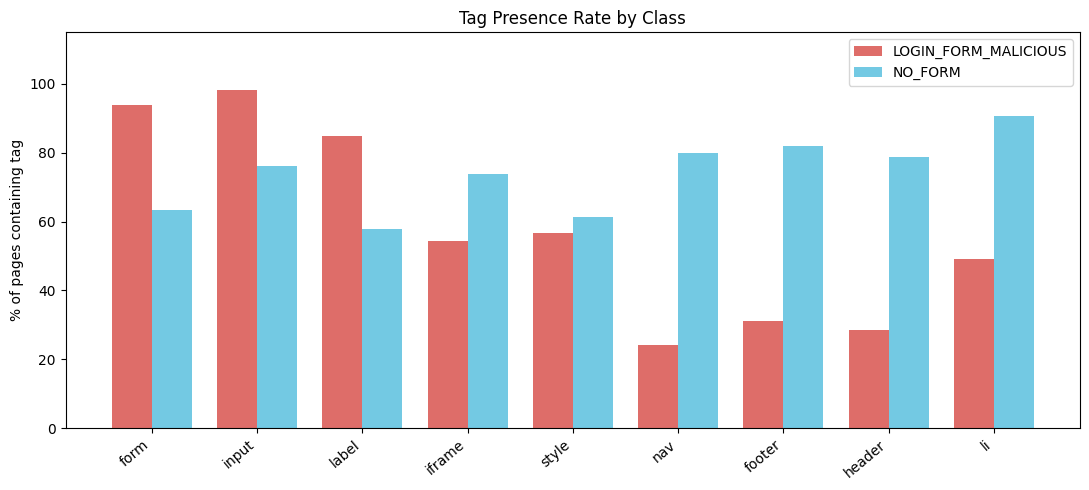

In [44]:
fig, ax = plt.subplots(figsize=(11, 5))
x = range(len(TAGS_OF_INTEREST))
width = 0.38

ax.bar([i - width/2 for i in x], presence["LOGIN_FORM_MALICIOUS"], width,
       label="LOGIN_FORM_MALICIOUS", color="#d9534f", alpha=0.85)
ax.bar([i + width/2 for i in x], presence["NO_FORM"], width,
       label="NO_FORM", color="#5bc0de", alpha=0.85)

ax.set_xticks(list(x))
ax.set_xticklabels(TAGS_OF_INTEREST, rotation=40, ha="right")
ax.set_ylabel("% of pages containing tag")
ax.set_title("Tag Presence Rate by Class")
ax.set_ylim(0, 115)
ax.legend()
plt.tight_layout()
plt.show()

## 7. Tags Group Analysis

Shows how combining tags progressively reduces false positives (no-form %) while maintaining high malicious coverage.

- **Part 1** — individual rates for each of the 5 credential group tags.
- **Part 2** — co-occurrence rates as tags are combined (pairs → triples → quads → 5-tag group).

In [45]:
mal_df = df[df["label"] == "LOGIN_FORM_MALICIOUS"]
nf_df  = df[df["label"] == "NO_FORM"]

GROUPS = [
    ["form", "input"],
    ["form", "label"],
    ["input", "label"],
    ["form", "iframe"],
    ["form", "input", "label"],
    ["form", "input", "iframe"],
    ["form", "label", "iframe"],
    ["input", "label", "style"],
    ["form", "input", "label", "iframe"],
    ["form", "input", "label", "style"],
    ["form", "input", "label", "iframe", "style"],
]

part2_rows = []
for g in GROUPS:
    cols  = [f"has_{t}" for t in g]
    match = df[cols].all(axis=1)
    m = round((match & (df["label"] == "LOGIN_FORM_MALICIOUS")).sum() / len(mal_df) * 100, 2)
    n = round((match & (df["label"] == "NO_FORM")).sum()           / len(nf_df)  * 100, 2)
    part2_rows.append({"Tag Group": " + ".join(g), "Malicious (%)": m, "No-Form (%)": n, "Gap": round(m - n, 2)})

part2 = pd.DataFrame(part2_rows).set_index("Tag Group")

display(part2)

,Malicious (%),No-Form (%),Gap
Tag Group,,,
form + input,93.74,63.07,30.67
form + label,82.46,48.07,34.39
input + label,84.85,56.78,28.07
form + iframe,52.73,49.08,3.65
form + input + label,82.46,48.07,34.39
form + input + iframe,52.62,48.91,3.71
form + label + iframe,49.77,38.86,10.91
input + label + style,53.64,39.36,14.28
form + input + label + iframe,49.77,38.86,10.91
